<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/tsf_task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

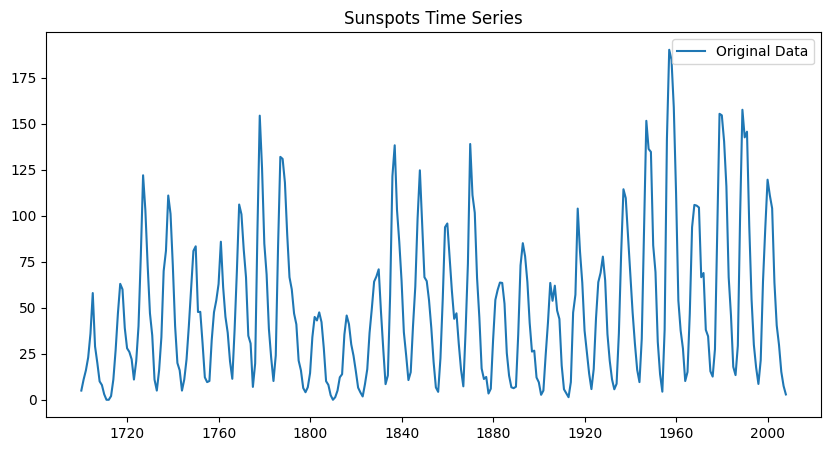

ADF Statistic: -2.8377807249381943
p-value: 0.053076421728120673

AR Model Summary:
                            AutoReg Model Results                             
Dep. Variable:            SUNACTIVITY   No. Observations:                  308
Model:                     AutoReg(2)   Log Likelihood               -1345.422
Method:               Conditional MLE   S.D. of innovations             19.646
Date:                Thu, 27 Aug 2026   AIC                           2698.843
Time:                        03:49:14   BIC                           2713.738
Sample:                    01-01-1703   HQIC                          2704.800
                         - 01-01-2008                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0272      1.123     -0.024      0.981      -2.228       2.174
SUNACTIVITY.L1     0.6696      0.05

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



MA Model Summary:
                               SARIMAX Results                                
Dep. Variable:            SUNACTIVITY   No. Observations:                  308
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1351.581
Date:                Thu, 27 Aug 2026   AIC                           2711.162
Time:                        03:49:15   BIC                           2726.082
Sample:                    01-01-1701   HQIC                          2717.128
                         - 01-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0042      2.464     -0.002      0.999      -4.833       4.825
ma.L1          0.6267      0.055     11.325      0.000       0.518       0.735
ma.L2          0.3386      0.056 

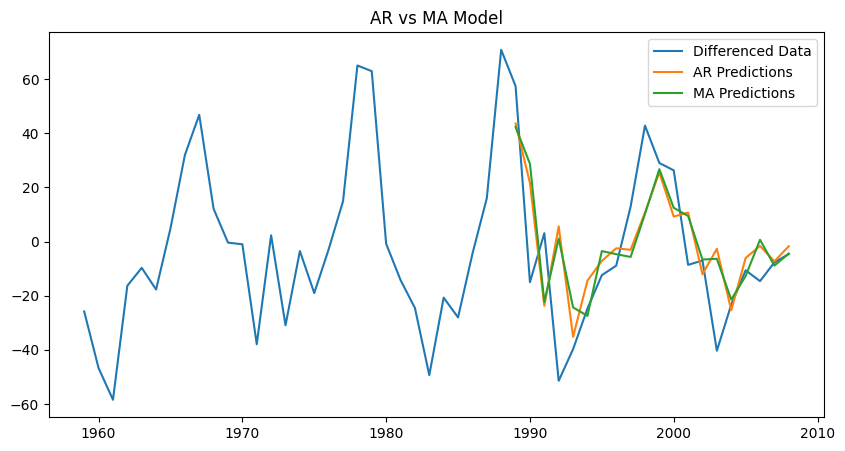

In [ ]:
# TASK 7
# Implement Autoregressive (AR) and Moving Average (MA) models

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.datasets import sunspots
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Step 2: Load Inbuilt Dataset
data = sunspots.load_pandas().data

# Convert to time series format
data['YEAR'] = pd.to_datetime(data['YEAR'], format='%Y')
data.set_index('YEAR', inplace=True)

ts = data['SUNACTIVITY']

# Step 3: Plot Data
plt.figure(figsize=(10, 5))
plt.plot(ts, label='Original Data')
plt.title('Sunspots Time Series')
plt.legend()
plt.show()

# Step 4: Check Stationarity
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Apply differencing
ts_diff = ts.diff().dropna()

# Step 5: AR Model
ar_model = AutoReg(ts_diff, lags=2)
ar_fit = ar_model.fit()

print("\nAR Model Summary:")
print(ar_fit.summary())

# AR Predictions
ar_pred = ar_fit.predict(
    start=len(ts_diff) - 20,
    end=len(ts_diff) - 1
)

# Step 6: MA Model
ma_model = ARIMA(ts_diff, order=(0, 0, 2))
ma_fit = ma_model.fit()

print("\nMA Model Summary:")
print(ma_fit.summary())

# MA Predictions
ma_pred = ma_fit.predict(
    start=len(ts_diff) - 20,
    end=len(ts_diff) - 1
)

# Step 7: Plot Results
plt.figure(figsize=(10, 5))

plt.plot(
    ts_diff[-50:],
    label='Differenced Data'
)

plt.plot(
    ar_pred,
    label='AR Predictions'
)

plt.plot(
    ma_pred,
    label='MA Predictions'
)

plt.legend()
plt.title('AR vs MA Model')
plt.show()